# Connect to Postgres database and setup tables

Now that we have a database up and running we want to be able to connect to it from a python/jupyter environment.

Below is an example of using GeoPandas to load and read data from the database. 

## Setup

In [91]:
from sqlalchemy import URL, create_engine
import geopandas as gpd
import dotenv
import os
import morpc

Load in environmental variables. These include the username and password to acces the database.

In [92]:
dotenv.load_dotenv(".env")

True

Create the URL for the location of the database. 

In [119]:
url = URL.create(
    "postgresql",
    username=os.environ.get('POSTGRES_USER'),
    password=os.environ.get('POSTGRES_PASSWORD'),
    host='localhost', # This is for the locally hosted database. Change to server IP if remote.
    port=5432,
    database='morpc-postgis'
)

Create the engine

In [94]:
engine = create_engine(url, echo=True)

## Load data

Get some data to load

In [102]:
gdf = morpc.census.geos.fetch_geos_from_scale_scope('region15', 'county')

Scope and Scale have same sumlevel, using Scope region15.



Downloading: 100%|██████████████████████████| 1/1 [00:03<00:00, 0.36 requests/s]


Change to column names to lower case. This is the default for postgres tables, and otherwise will it will require more complicated sql strings

In [120]:
gdf = gdf.reset_index()
gdf.columns = [column.lower() for column in gdf.columns]

View the data

In [106]:
gdf

,geo_id,name,geometry
0,0500000US39047,Fayette County,"POLYGON ((-83.37271 39.37742, -83.37267 39.377..."
1,0500000US39091,Logan County,"POLYGON ((-84.00237 40.48311, -84.00232 40.469..."
2,0500000US39129,Pickaway County,"POLYGON ((-82.84295 39.56148, -82.84294 39.561..."
3,0500000US39073,Hocking County,"POLYGON ((-82.40223 39.39023, -82.40107 39.390..."
4,0500000US39041,Delaware County,"POLYGON ((-83.02208 40.41888, -83.02094 40.432..."
5,0500000US39045,Fairfield County,"POLYGON ((-82.49033 39.6617, -82.48837 39.6615..."
6,0500000US39141,Ross County,"POLYGON ((-82.9982 39.48006, -82.9982 39.48036..."
7,0500000US39083,Knox County,"POLYGON ((-82.18818 40.38335, -82.18795 40.387..."
8,0500000US39049,Franklin County,"POLYGON ((-83.21025 40.06927, -83.21028 40.069..."
9,0500000US39089,Licking County,"POLYGON ((-82.46276 40.24515, -82.47418 40.245..."


Load the data in to the table.

> NOTE: We are using underscores for the table names. This is also the default in postgres tables and will help with constructing sql strings.

GeoPandas allows us to handle if the table already exists. In this case we will replace the table if it exists. Other options are 'fail' and 'append'

In [122]:
gdf.to_postgis('morpc_geos_region15_county', engine, if_exists='replace') 

2026-04-15 09:55:30,321 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-15 09:55:30,323 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_namespace.nspname = %(nspname_1)s
2026-04-15 09:55:30,324 INFO sqlalchemy.engine.Engine [cached since 898.9s ago] {'table_name': 'morpc_geos_region15_county', 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'public'}
2026-04-15 09:55:30,326 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog

Check for the table

In [108]:
from sqlalchemy import inspect

inspect(engine).get_table_names()

2026-04-15 09:42:04,806 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-15 09:42:04,807 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s]) AND pg_catalog.pg_class.relpersistence != %(relpersistence_1)s AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2026-04-15 09:42:04,808 INFO sqlalchemy.engine.Engine [cached since 92.29s ago] {'param_1': 'r', 'param_2': 'p', 'relpersistence_1': 't', 'nspname_1': 'pg_catalog'}
2026-04-15 09:42:04,811 INFO sqlalchemy.engine.Engine ROLLBACK


['spatial_ref_sys', 'morpc_geos_region15_county']

Check the columns in the table

In [109]:
inspect(engine).get_columns('morpc_geos_region15_county')

2026-04-15 09:42:05,672 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-15 09:42:05,674 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_attribute.attname AS name, pg_catalog.format_type(pg_catalog.pg_attribute.atttypid, pg_catalog.pg_attribute.atttypmod) AS format_type, (SELECT pg_catalog.pg_get_expr(pg_catalog.pg_attrdef.adbin, pg_catalog.pg_attrdef.adrelid) AS pg_get_expr_1 
FROM pg_catalog.pg_attrdef 
WHERE pg_catalog.pg_attrdef.adrelid = pg_catalog.pg_attribute.attrelid AND pg_catalog.pg_attrdef.adnum = pg_catalog.pg_attribute.attnum AND pg_catalog.pg_attribute.atthasdef) AS "default", pg_catalog.pg_attribute.attnotnull AS not_null, pg_catalog.pg_class.relname AS table_name, pg_catalog.pg_description.description AS comment, pg_catalog.pg_attribute.attgenerated AS generated, (SELECT json_build_object(%(json_build_object_2)s, pg_catalog.pg_attribute.attidentity = %(attidentity_1)s, %(json_build_object_3)s, pg_catalog.pg_sequence.seqstart, %(json_build_object_4)s, pg_catalog

[{'name': 'geo_id',
  'type': TEXT(),
  'nullable': True,
  'default': None,
  'autoincrement': False,
  'comment': None},
 {'name': 'name',
  'type': TEXT(),
  'nullable': True,
  'default': None,
  'autoincrement': False,
  'comment': None},
 {'name': 'geometry',
  'type': Geometry(geometry_type='POLYGON', srid=4326, dimension=2, from_text='ST_GeomFromEWKT', name='geometry'),
  'nullable': True,
  'default': None,
  'autoincrement': False,
  'comment': None}]

## Read the data from the database

In [110]:
sql = 'SELECT * FROM morpc_geos_region15_county'
gdf = gpd.read_postgis(sql, engine, geom_col='geometry')

2026-04-15 09:42:08,777 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-15 09:42:08,778 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2026-04-15 09:42:08,779 INFO sqlalchemy.engine.Engine [cached since 97.33s ago] {'table_name': 'SELECT * FROM morpc_geos_region15_county', 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2026-04-15 09:42:08,782 INFO sqlalchemy.engine.Engine SELECT * FROM morpc_geos_region15_county
2026-04-15 09:42:08,783 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-04-15 09:42:08,787 INFO sqlalc

In [111]:
gdf

,geo_id,name,geometry
0,0500000US39047,Fayette County,"POLYGON ((-83.37271 39.37742, -83.37267 39.377..."
1,0500000US39091,Logan County,"POLYGON ((-84.00237 40.48311, -84.00232 40.469..."
2,0500000US39129,Pickaway County,"POLYGON ((-82.84295 39.56148, -82.84294 39.561..."
3,0500000US39073,Hocking County,"POLYGON ((-82.40223 39.39023, -82.40107 39.390..."
4,0500000US39041,Delaware County,"POLYGON ((-83.02208 40.41888, -83.02094 40.432..."
5,0500000US39045,Fairfield County,"POLYGON ((-82.49033 39.6617, -82.48837 39.6615..."
6,0500000US39141,Ross County,"POLYGON ((-82.9982 39.48006, -82.9982 39.48036..."
7,0500000US39083,Knox County,"POLYGON ((-82.18818 40.38335, -82.18795 40.387..."
8,0500000US39049,Franklin County,"POLYGON ((-83.21025 40.06927, -83.21028 40.069..."
9,0500000US39089,Licking County,"POLYGON ((-82.46276 40.24515, -82.47418 40.245..."


<Axes: >

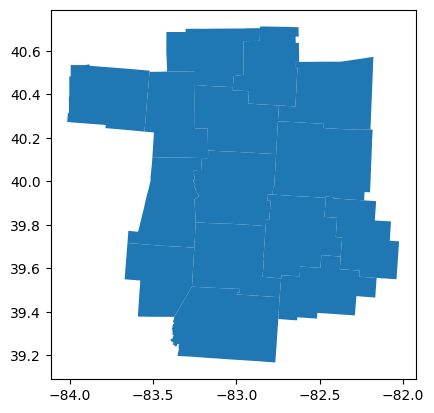

In [112]:
gdf.plot()

In [113]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Query the data with SQL strings

In [116]:
sql = "SELECT name, geometry from morpc_geos_region15_county WHERE name = 'Franklin County'"
gdf = gpd.read_postgis(sql, engine, geom_col='geometry')

2026-04-15 09:42:40,990 INFO sqlalchemy.engine.Engine BEGIN (implicit)


2026-04-15 09:42:40,991 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2026-04-15 09:42:40,992 INFO sqlalchemy.engine.Engine [cached since 129.5s ago] {'table_name': "SELECT name, geometry from morpc_geos_region15_county WHERE name = 'Franklin County'", 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2026-04-15 09:42:40,994 INFO sqlalchemy.engine.Engine SELECT name, geometry from morpc_geos_region15_county WHERE name = 'Franklin County'
2026-04-15 09:42:40,994 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-04-15 09:42:4

In [117]:
gdf

,name,geometry
0,Franklin County,"POLYGON ((-83.21025 40.06927, -83.21028 40.069..."


<Axes: >

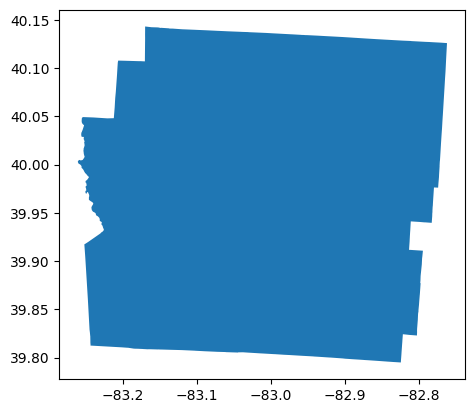

In [118]:
gdf.plot()